In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import probplot

# Read file
parquet_path = '/share_snc/snc/JuanMonleon/parquets/perturbation_matrix_20260107_125626_master.parquet'
df = pd.read_parquet(parquet_path)

In [2]:
df

,Sample_ID,Fe56_MT2_1.000e-11_4.000e-09,Fe56_MT2_4.000e-09_1.000e-08,Fe56_MT2_1.000e-08_2.530e-08,Fe56_MT2_2.530e-08_4.000e-08,Fe56_MT2_4.000e-08_5.000e-08,Fe56_MT2_5.000e-08_6.000e-08,Fe56_MT2_6.000e-08_8.000e-08,Fe56_MT2_8.000e-08_1.000e-07,Fe56_MT2_1.000e-07_1.500e-07,...,Fe56_MT115_4.700e-01_6.000e-01,Fe56_MT115_6.000e-01_7.500e-01,Fe56_MT115_7.500e-01_8.611e-01,Fe56_MT115_8.611e-01_1.200e+00,Fe56_MT115_1.200e+00_1.500e+00,Fe56_MT115_1.500e+00_1.850e+00,Fe56_MT115_1.850e+00_3.000e+00,Fe56_MT115_3.000e+00_4.304e+00,Fe56_MT115_4.304e+00_6.434e+00,Fe56_MT115_6.434e+00_2.000e+01
0,1,0.972302,0.981552,1.056350,1.070745,1.076773,1.024870,1.028392,1.033682,1.053843,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.358384
1,2,1.117853,1.069475,1.112167,1.059199,1.036766,1.061073,1.056883,1.052294,1.043151,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.928794
2,3,1.051090,1.045768,1.069259,1.059494,1.054993,1.045816,1.056144,1.073185,1.038886,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.775772
3,4,0.868759,0.892067,0.853520,0.873637,0.882245,0.915878,0.905497,0.887408,0.897925,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.557516
4,5,0.897056,0.929964,0.866900,0.915025,0.936462,0.934674,0.919229,0.892540,0.919295,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.239892
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1019,1020,0.782504,0.825433,0.968680,0.968927,0.968684,0.965735,0.968808,0.971914,0.991680,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.615567
1020,1021,0.898510,0.928431,1.035252,1.051845,1.058805,1.045375,1.041155,1.033143,1.043590,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.271538
1021,1022,1.065807,1.050998,0.998054,0.996647,0.995789,1.027555,1.036361,1.051176,1.012604,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.671885
1022,1023,1.041163,1.013143,1.012581,1.018435,1.020788,0.993237,0.984514,0.971460,0.970051,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.059725


Column: Fe56_MT2_5.000e-08_6.000e-08
Mean: 1.000061
Std Dev: 0.054590
Number of samples: 1024


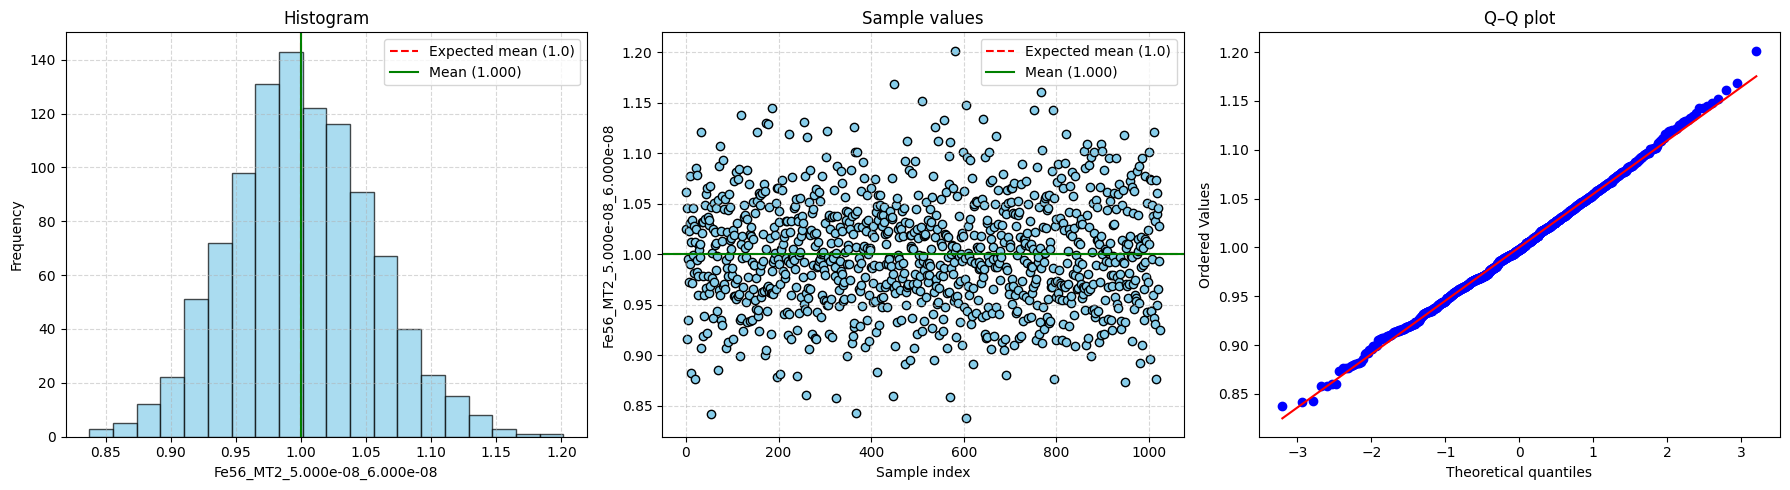

In [3]:


# Choose the 6th column (index 5 if zero-based)
fixed_column = df.columns[6]
values = df[fixed_column].astype(float).values

# Stats
mean_val = np.mean(values)
std_val = np.std(values, ddof=1)

print(f"Column: {fixed_column}")
print(f"Mean: {mean_val:.6f}")
print(f"Std Dev: {std_val:.6f}")
print(f"Number of samples: {len(values)}")

# Create subplots: histogram + scatter + Q-Q
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Histogram
axes[0].hist(values, bins=20, alpha=0.7, color='skyblue', edgecolor='black')
axes[0].axvline(1.0, color='red', linestyle='--', label='Expected mean (1.0)')
axes[0].axvline(mean_val, color='green', linestyle='-', label=f'Mean ({mean_val:.3f})')
axes[0].set_title('Histogram')
axes[0].set_xlabel(fixed_column)
axes[0].set_ylabel('Frequency')
axes[0].legend()
axes[0].grid(True, linestyle='--', alpha=0.5)

# 2. Scatter
axes[1].scatter(range(len(values)), values, color='skyblue', edgecolor='black')
axes[1].axhline(1.0, color='red', linestyle='--', label='Expected mean (1.0)')
axes[1].axhline(mean_val, color='green', linestyle='-', label=f'Mean ({mean_val:.3f})')
axes[1].set_title('Sample values')
axes[1].set_xlabel('Sample index')
axes[1].set_ylabel(fixed_column)
axes[1].legend()
axes[1].grid(True, linestyle='--', alpha=0.5)

# 3. Q-Q plot
probplot(values, dist="norm", plot=axes[2])
axes[2].get_lines()[1].set_color('red')  # Line of best fit in red
axes[2].set_title('Q–Q plot')

plt.tight_layout()
plt.show()


In [4]:
7485/128

58.4765625